In [ ]:
# Step 1: Load CSV and audit
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sns.set(style="whitegrid")

CSV_PATH = "/content/ecommerce_furniture_dataset_2024.csv"  # adjust if needed
df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)
display(df.head(3))
print("\nInfo:"); df.info()
print("\nMissing values:\n", df.isnull().sum())


Shape: (2000, 5)


,productTitle,originalPrice,price,sold,tagText
0,Dresser For Bedroom With 9 Fabric Drawers Ward...,NaN,$46.79,600,Free shipping
1,Outdoor Conversation Set 4 Pieces Patio Furnit...,NaN,$169.72,0,Free shipping
2,Desser For Bedroom With 7 Fabric Drawers Organ...,$78.4,$39.46,7,Free shipping



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   productTitle   2000 non-null   object
 1   originalPrice  487 non-null    object
 2   price          2000 non-null   object
 3   sold           2000 non-null   int64 
 4   tagText        1997 non-null   object
dtypes: int64(1), object(4)
memory usage: 78.3+ KB

Missing values:
 productTitle        0
originalPrice    1513
price               0
sold                0
tagText             3
dtype: int64


In [ ]:
# Step 2: Clean -> numeric, simple imputations, and ONE engineered feature

import numpy as np

# 1) Make 'price' and 'originalPrice' numeric (strip currency, commas, spaces)
df['price'] = pd.to_numeric(
    df['price'].astype(str).replace(r'[^\d.]', '', regex=True),
    errors='coerce'
)
df['originalPrice'] = pd.to_numeric(
    df['originalPrice'].astype(str).replace(r'[^\d.]', '', regex=True),
    errors='coerce'
)

# 2) Fill tiny missing in tagText
df['tagText'] = df['tagText'].fillna('Unknown')

# 3) Beginner-friendly imputation for originalPrice so we can compute discount
#    - if missing: assume no discount -> originalPrice = price
#    - if still NaN (very rare): fallback to median(price)
df['originalPrice'] = df['originalPrice'].fillna(df['price'])
df['originalPrice'] = df['originalPrice'].fillna(df['price'].median())

# 4) Safety for price (should already be present)
df['price'] = df['price'].fillna(df['price'].median())

# 5) ONE engineered feature: discount_percent = ((orig - price)/orig)*100
den = df['originalPrice'].replace(0, np.nan)  # avoid divide-by-zero
df['discount_percent'] = ((df['originalPrice'] - df['price']) / den) * 100
df['discount_percent'] = df['discount_percent'].fillna(0).clip(0, 100)

# 6) Quick sanity check
print("Dtypes after cleaning:\n", df.dtypes)
print("\nMissing after cleaning:\n", df.isnull().sum())
df.head(3)


Dtypes after cleaning:
 productTitle         object
originalPrice       float64
price               float64
sold                  int64
tagText              object
discount_percent    float64
dtype: object

Missing after cleaning:
 productTitle        0
originalPrice       0
price               0
sold                0
tagText             0
discount_percent    0
dtype: int64


,productTitle,originalPrice,price,sold,tagText,discount_percent
0,Dresser For Bedroom With 9 Fabric Drawers Ward...,46.79,46.79,600,Free shipping,0.000000
1,Outdoor Conversation Set 4 Pieces Patio Furnit...,169.72,169.72,0,Free shipping,0.000000
2,Desser For Bedroom With 7 Fabric Drawers Organ...,78.40,39.46,7,Free shipping,49.668367


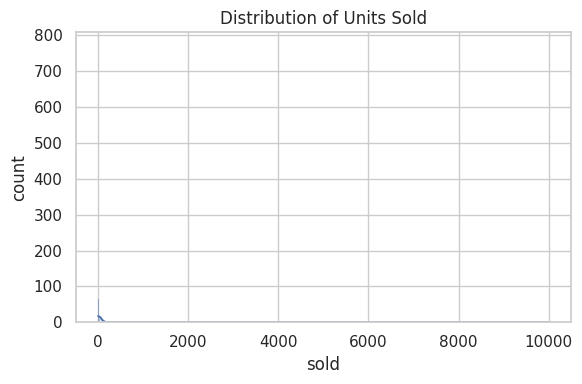

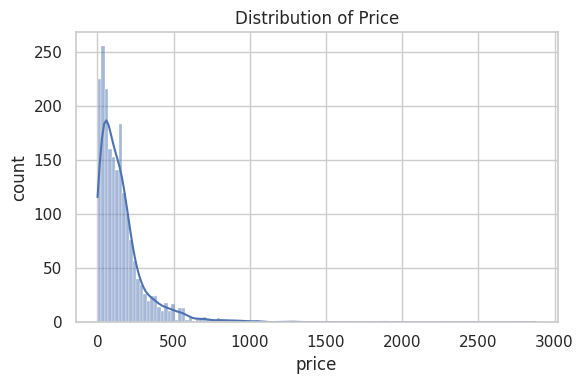

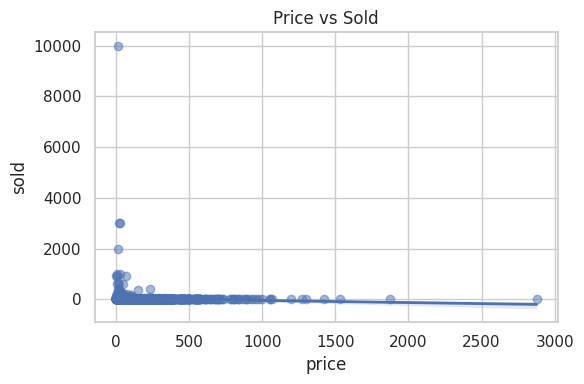

,count,mean,std,min,25%,50%,75%,max
price,2000.0,156.56,176.94,0.99,48.53,114.08,193.49,2876.38
originalPrice,2000.0,189.54,260.61,1.01,58.60,121.63,211.79,3265.13
discount_percent,2000.0,11.50,22.23,0.00,0.00,0.00,0.00,91.46
sold,2000.0,23.49,254.09,0.00,1.00,3.00,9.00,10000.00


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# 3.1 Distribution of Sold
plt.figure(figsize=(6,4))
sns.histplot(df['sold'], kde=True)
plt.title('Distribution of Units Sold'); plt.xlabel('sold'); plt.ylabel('count')
plt.tight_layout(); plt.show()

# 3.2 Distribution of Price
plt.figure(figsize=(6,4))
sns.histplot(df['price'], kde=True)
plt.title('Distribution of Price'); plt.xlabel('price'); plt.ylabel('count')
plt.tight_layout(); plt.show()

# 3.3 Price vs Sold (with trend line)
plt.figure(figsize=(6,4))
sns.regplot(x='price', y='sold', data=df, scatter_kws={'alpha':0.5}, line_kws={'linewidth':2})
plt.title('Price vs Sold'); plt.xlabel('price'); plt.ylabel('sold')
plt.tight_layout(); plt.show()

# (Optional for report) Quick summary table for numeric columns
display(df[['price','originalPrice','discount_percent','sold']].describe().T.round(2))


=== Linear Regression (log-target + winsorize) ===
MSE: 1725.64
R² : -0.005

=== Random Forest (log-target + winsorize) ===
MSE: 1551.08
R² : 0.097


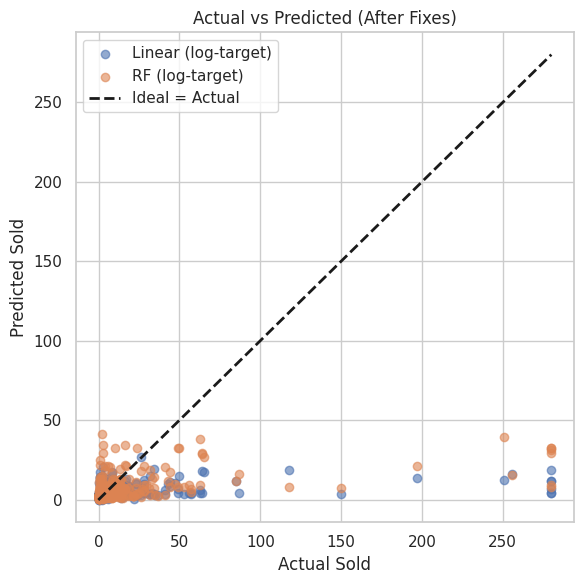

In [ ]:
# === Tiny Improvement Pack: winsorize + log-target (simple & safe) ===
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1) Winsorize (cap outliers at 99th percentile)
sold_cap = df['sold'].quantile(0.99)
price_cap = df['price'].quantile(0.99)
df['sold_cap']  = df['sold'].clip(upper=sold_cap)
df['price_cap'] = df['price'].clip(upper=price_cap)

# 2) Feature set stays ultra-simple
X = df[['price_cap', 'originalPrice', 'discount_percent']].copy()
y = df['sold_cap'].astype(float)

# 3) Log-target to stabilize skew
y_log = np.log1p(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.20, random_state=42
)

# 4) Linear Regression (log-target)
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr_log = lr.predict(X_test)
pred_lr = np.expm1(pred_lr_log)               # back to original scale
y_test_orig = np.expm1(y_test)

mse_lr = mean_squared_error(y_test_orig, pred_lr)
r2_lr  = r2_score(y_test_orig, pred_lr)

print("=== Linear Regression (log-target + winsorize) ===")
print(f"MSE: {mse_lr:.2f}")
print(f"R² : {r2_lr:.3f}")

# 5) Random Forest (log-target) — small, stable settings
rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=6,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
pred_rf_log = rf.predict(X_test)
pred_rf = np.expm1(pred_rf_log)

mse_rf = mean_squared_error(y_test_orig, pred_rf)
r2_rf  = r2_score(y_test_orig, pred_rf)

print("\n=== Random Forest (log-target + winsorize) ===")
print(f"MSE: {mse_rf:.2f}")
print(f"R² : {r2_rf:.3f}")

# 6) One clear comparison visual (Actual vs Predicted, both models)
plt.figure(figsize=(6,6))
plt.scatter(y_test_orig, pred_lr, alpha=0.6, label='Linear (log-target)')
plt.scatter(y_test_orig, pred_rf, alpha=0.6, label='RF (log-target)')
mn, mx = min(y_test_orig.min(), pred_lr.min(), pred_rf.min()), max(y_test_orig.max(), pred_lr.max(), pred_rf.max())
plt.plot([mn, mx], [mn, mx], 'k--', lw=2, label='Ideal = Actual')
plt.title('Actual vs Predicted (After Fixes)')
plt.xlabel('Actual Sold'); plt.ylabel('Predicted Sold')
plt.legend(); plt.tight_layout(); plt.show()



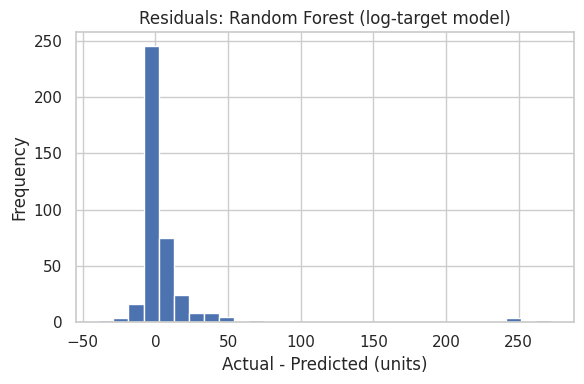

In [ ]:
# Residuals for RF (in original units)
import matplotlib.pyplot as plt
import numpy as np

residuals = y_test_orig - pred_rf
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30)
plt.title('Residuals: Random Forest (log-target model)')
plt.xlabel('Actual - Predicted (units)')
plt.ylabel('Frequency')
plt.tight_layout(); plt.show()


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Linear (log-target)", "Random Forest (log-target)"],
    "MSE":   [mse_lr, mse_rf],
    "R2":    [r2_lr,  r2_rf]
})
print("=== Results Summary ===")
display(results)

# Optional: show RF feature importances (on the 3 features we used)
importances = pd.Series(rf.feature_importances_,
                        index=["price_cap","originalPrice","discount_percent"]).sort_values(ascending=False)
print("\nRandom Forest Feature Importances:")
display(importances.round(4))


=== Results Summary ===


,Model,MSE,R2
0,Linear (log-target),1725.641735,-0.004511
1,Random Forest (log-target),1551.082408,0.097102



Random Forest Feature Importances:


,0
price_cap,0.5135
discount_percent,0.3014
originalPrice,0.1851
